In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [57]:
df=pd.read_csv("housing.csv")

In [58]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [59]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [60]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [61]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [62]:
df=df.drop(['longitude','ocean_proximity'],axis=1)

In [63]:
df

,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...
20635,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [64]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('median_house_value',axis=1),df['median_house_value'],test_size=0.2,random_state=42)

In [65]:
lr=LinearRegression()

In [66]:
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)

0.5530778105269334

In [67]:
lr=LinearRegression()
np.mean(cross_val_score(lr,x_train,y_train,scoring="r2"))

np.float64(0.5752157820200667)

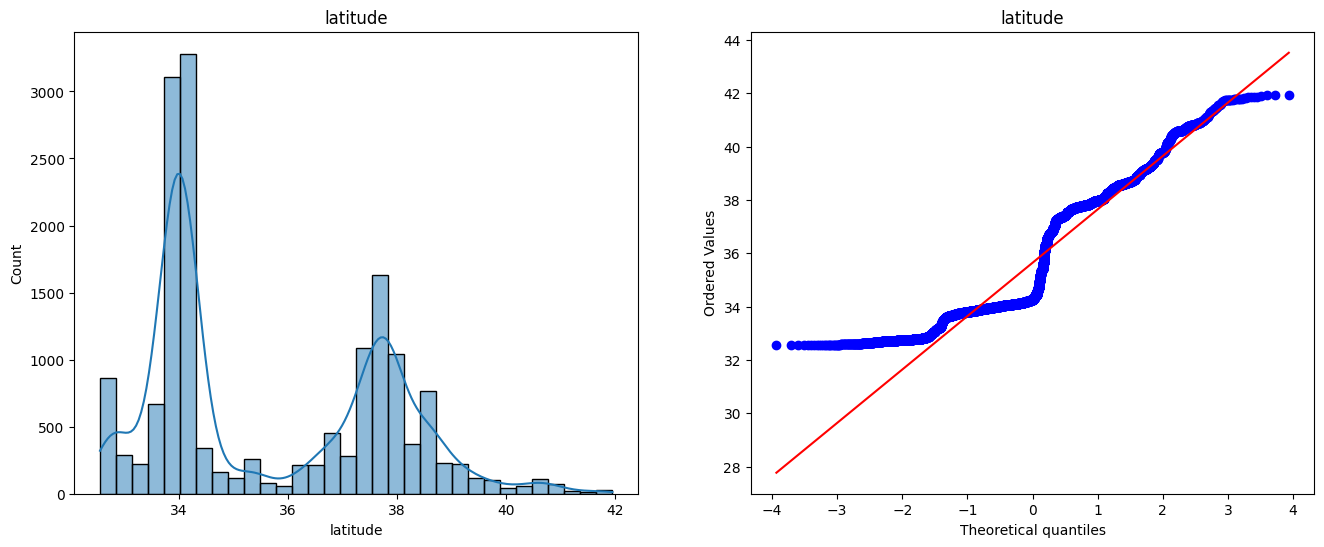

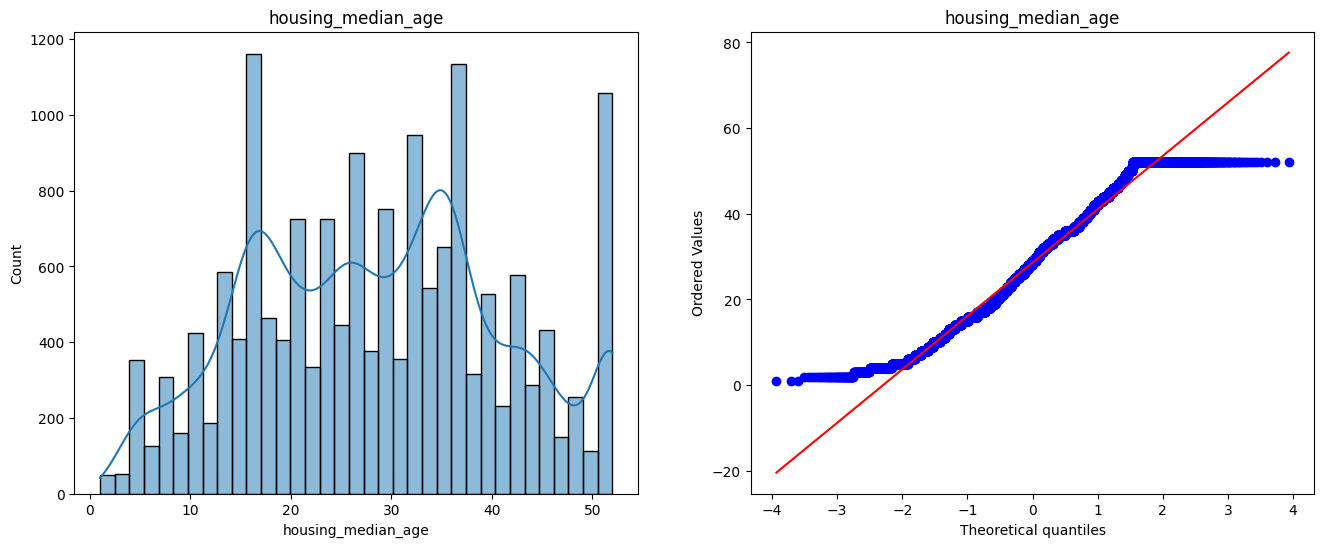

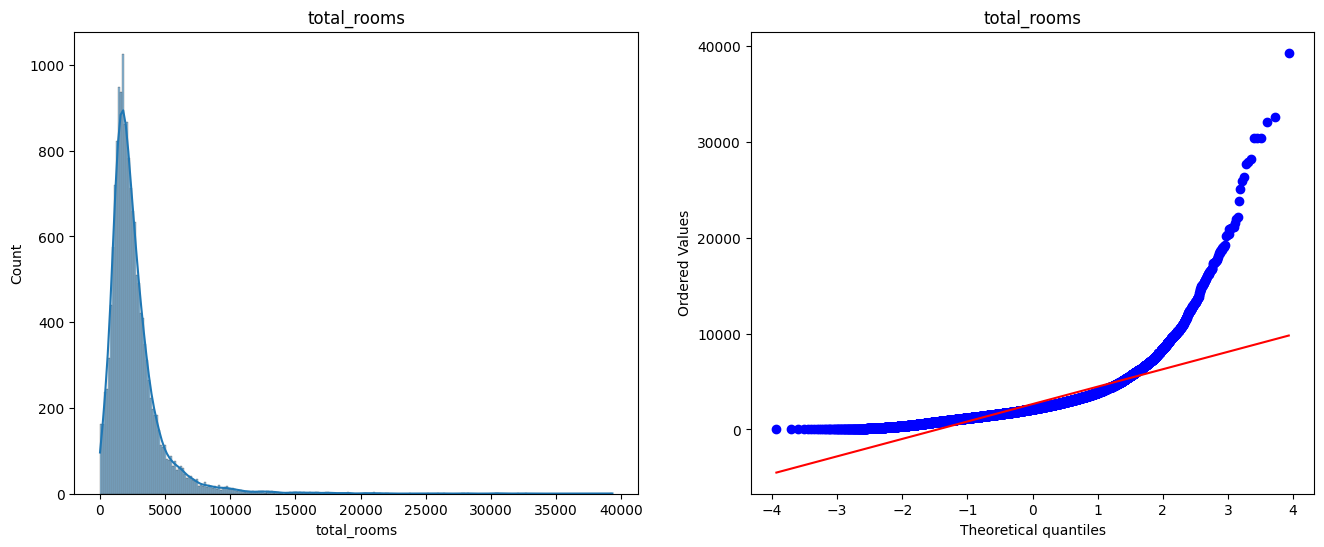

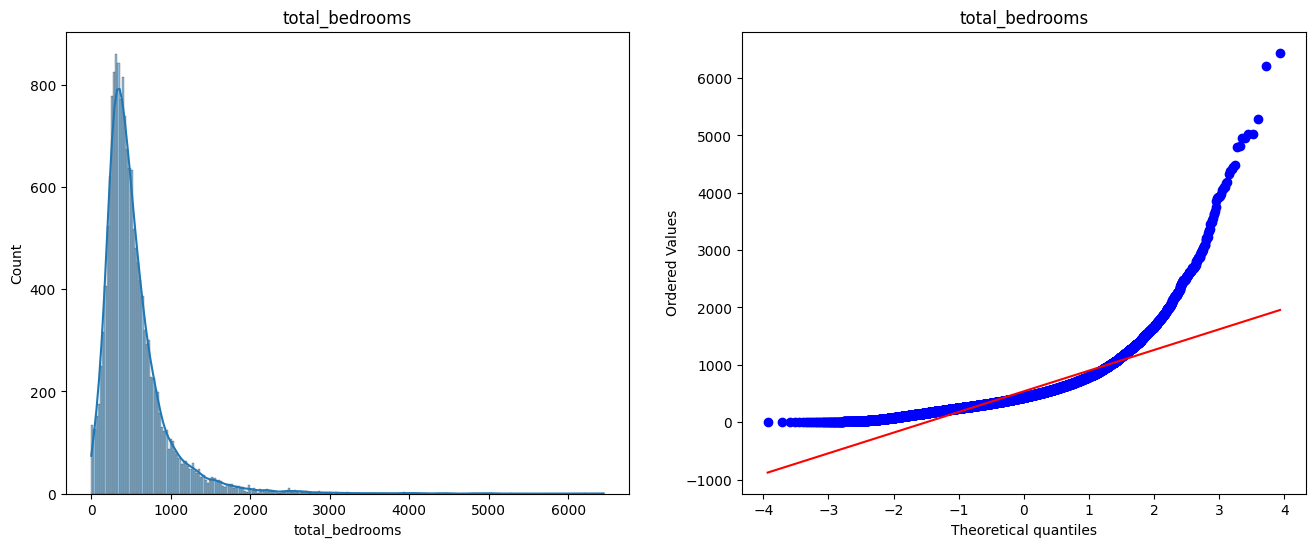

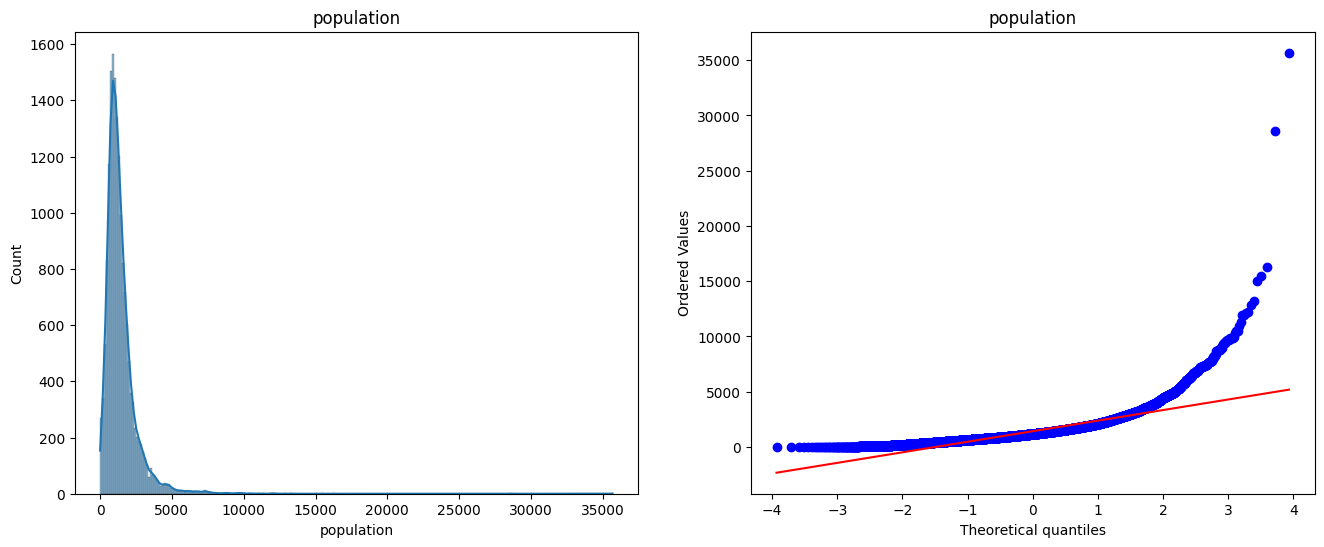

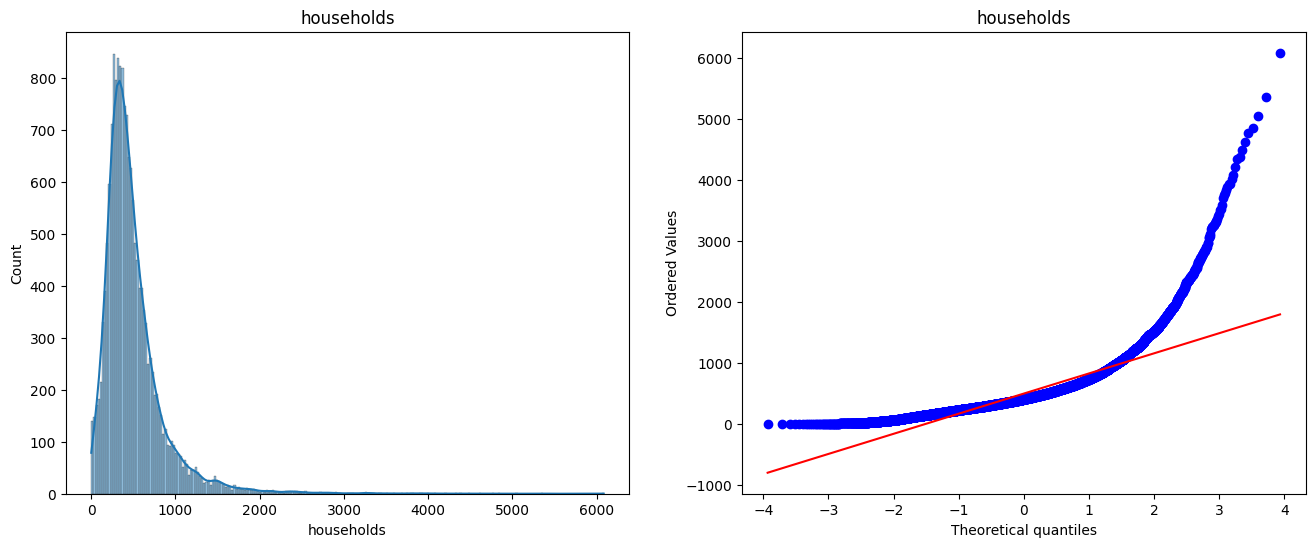

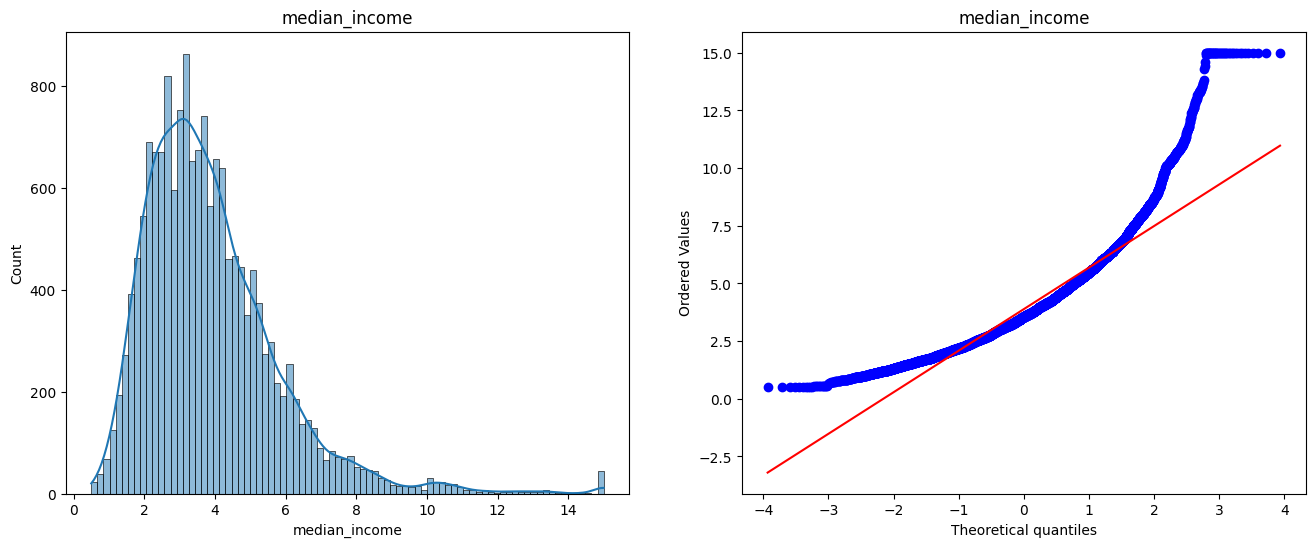

In [68]:
# Plotting the distplots without any transformation

for col in x_train.columns:
    plt.figure(figsize=(16,6))
    plt.subplot(121)
    sns.histplot(x_train[col],kde=True)
    
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [90]:
pt=PowerTransformer(method='box-cox')
x_train_transformed=pt.fit_transform(x_train)
x_test_transformed=pt.transform(x_test)
x_train_transformed =pd.DataFrame(x_train_transformed)
pd.DataFrame({'cols':x_train.columns,'box_cox_lambdas':pt.lambdas_})


,cols,box_cox_lambdas
0,latitude,-5.143948
1,housing_median_age,0.806377
2,total_rooms,0.222153
3,total_bedrooms,0.226055
4,population,0.235329
5,households,0.246385
6,median_income,0.097489


In [70]:
lr=LinearRegression()
lr.fit(x_train_transformed,y_train)
y_pred2=lr.predict(x_test_transformed)
r2_score(y_test,y_pred)


0.5530778105269334

In [71]:
lr=LinearRegression()
np.mean(cross_val_score(lr,x_train_transformed,y_train,scoring="r2"))

np.float64(0.5627054249021104)

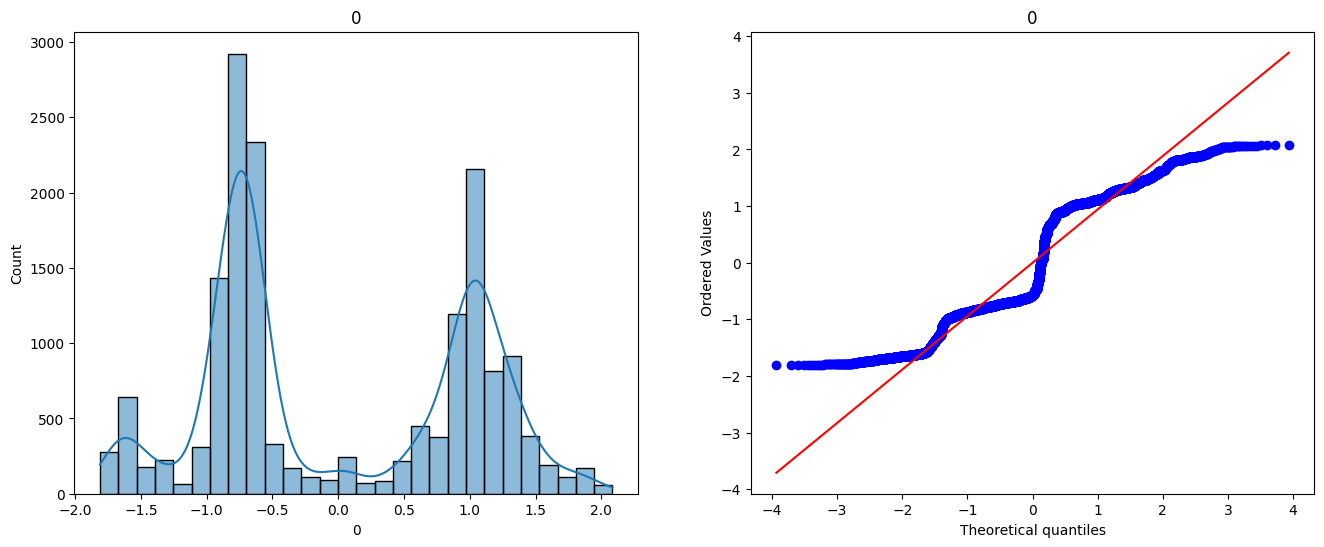

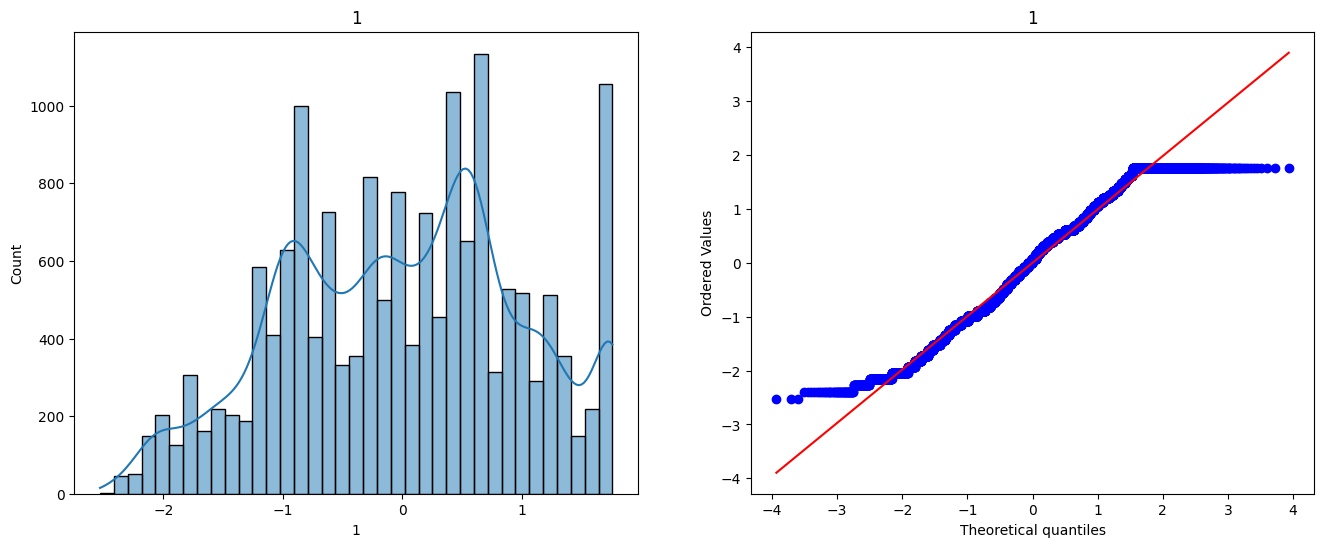

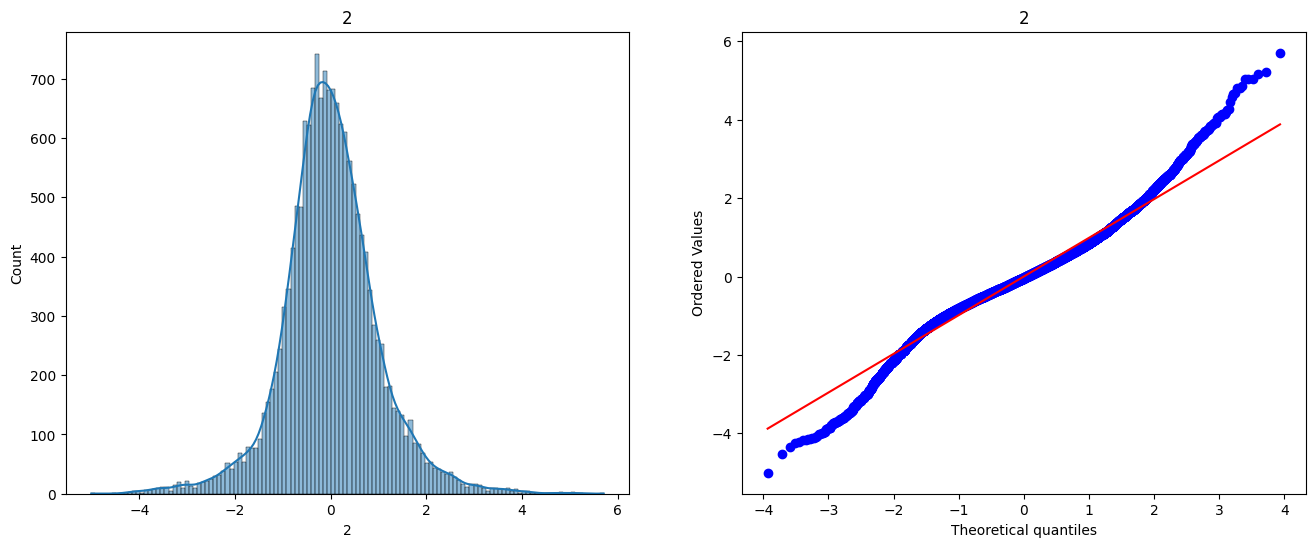

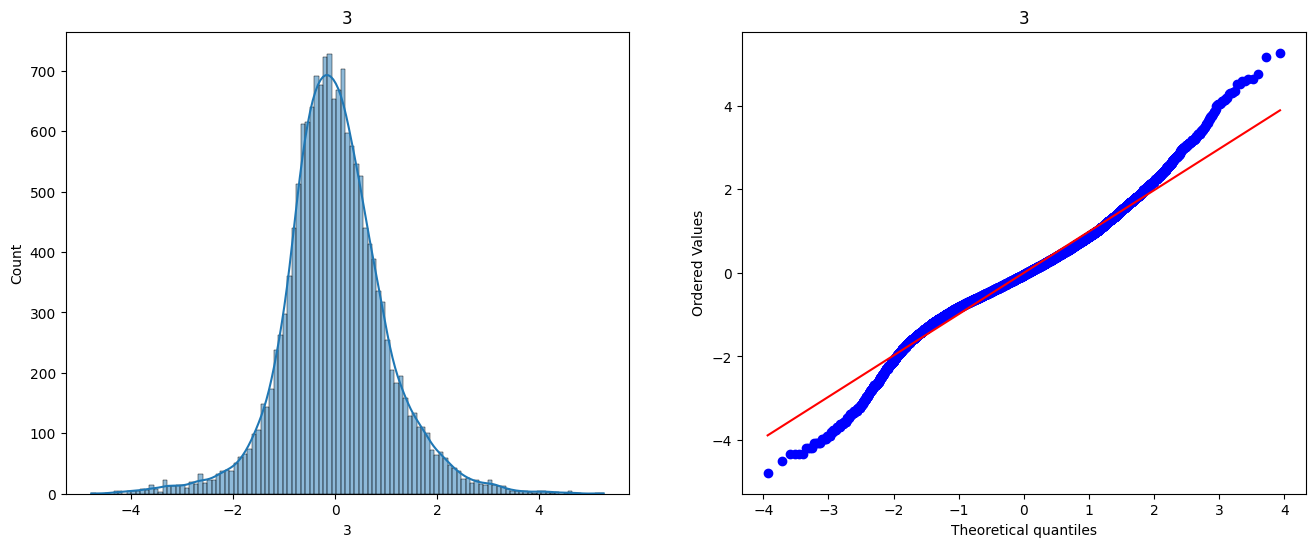

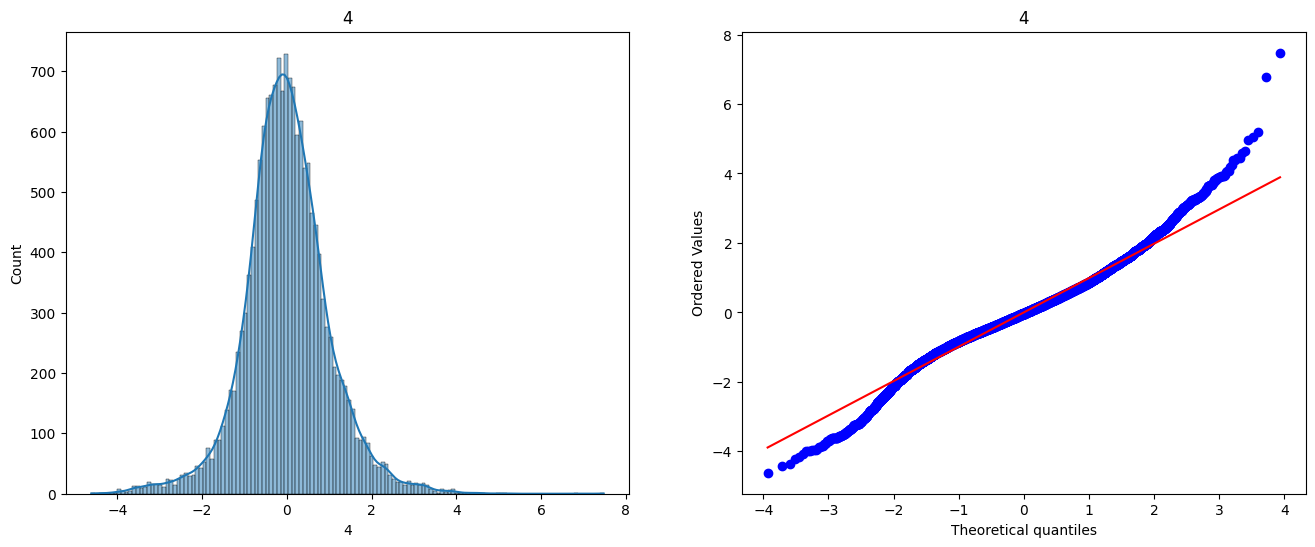

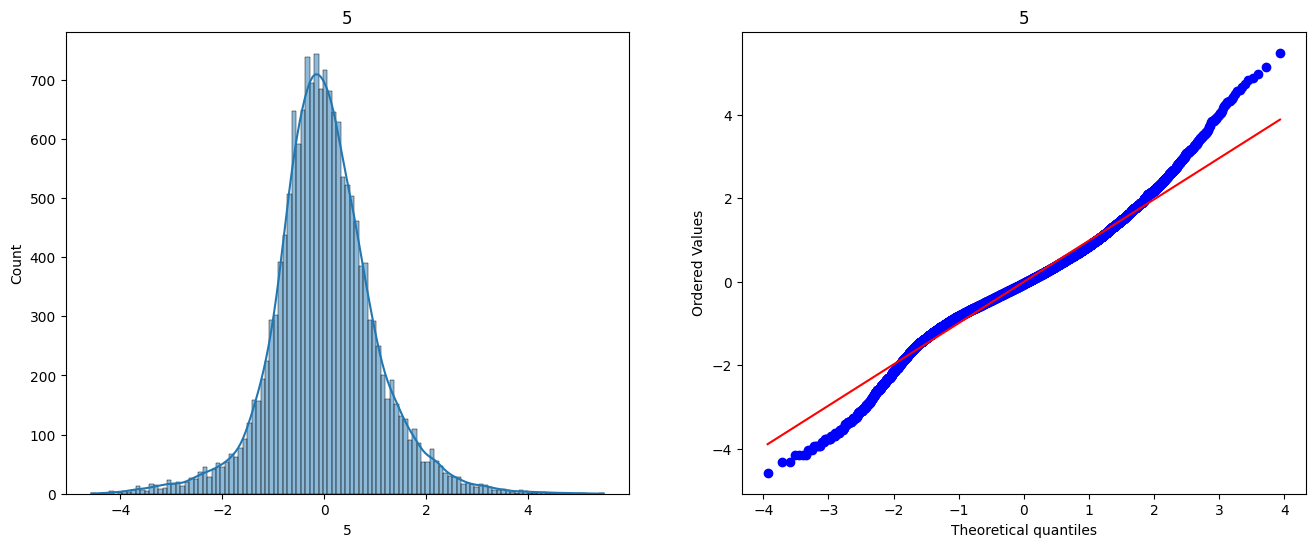

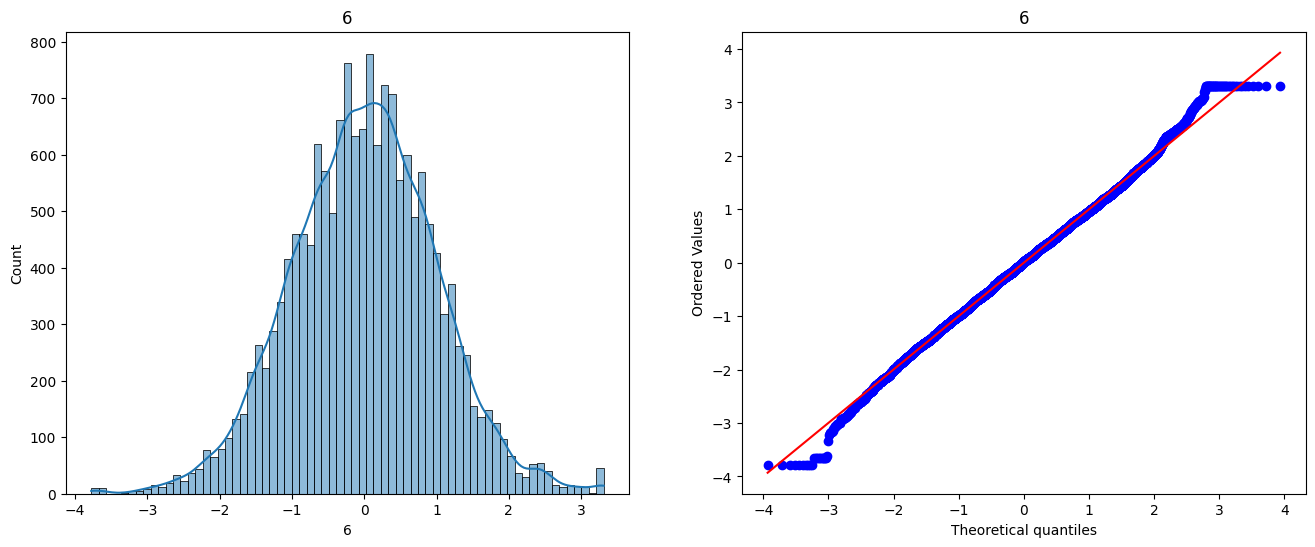

In [72]:
# Plotting the histplots without any transformation

for col in x_train_transformed.columns:
    plt.figure(figsize=(16,6))
    plt.subplot(121)
    sns.histplot(x_train_transformed[col],kde=True)
    
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train_transformed[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [89]:
pt1=PowerTransformer(method='yeo-johnson')
x_train_transformed2=pt1.fit_transform(x_train)
x_test_transformed2=pt1.transform(x_test)
x_train_transformed2=pd.DataFrame(x_train_transformed2)
pd.DataFrame({'cols':x_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,Yeo_Johnson_lambdas
0,latitude,-5.303354
1,housing_median_age,0.804946
2,total_rooms,0.220692
3,total_bedrooms,0.219769
4,population,0.233131
5,households,0.240230
6,median_income,-0.189843


In [85]:
lr=LinearRegression()
lr.fit(x_train_transformed2,y_train)
y_pred3=lr.predict(x_test)
r2_score(y_test,y_pred)

c:\Users\goswa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


0.5530778105269334

In [86]:
lr=LinearRegression()
np.mean(cross_val_score(lr,x_train_transformed2,y_train,scoring='r2'))

np.float64(0.5639874444919263)

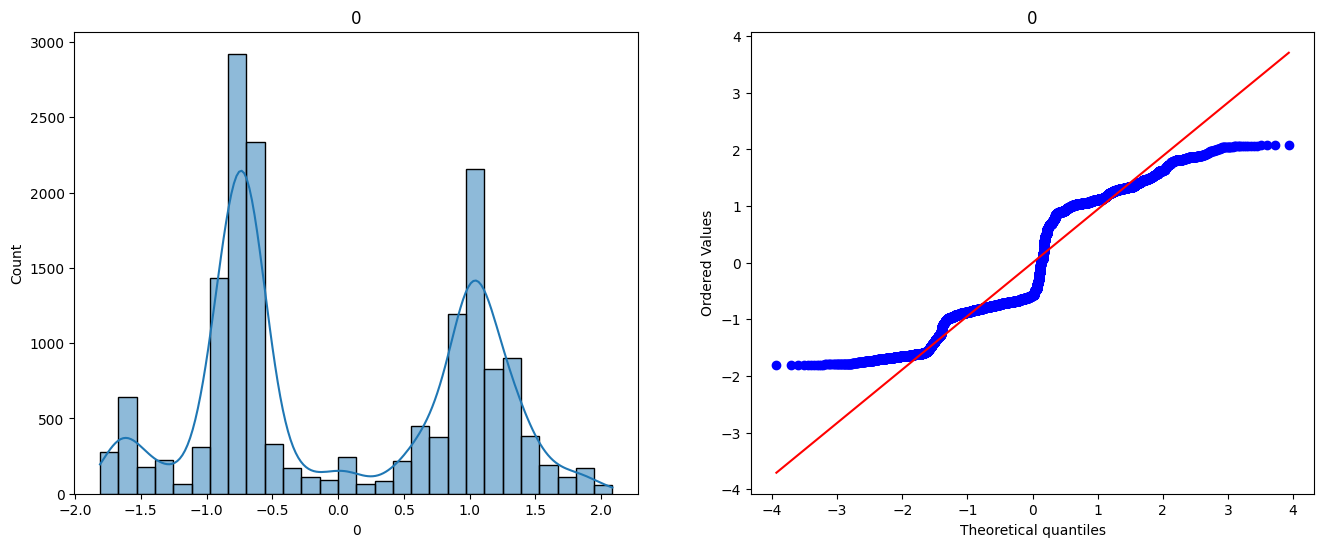

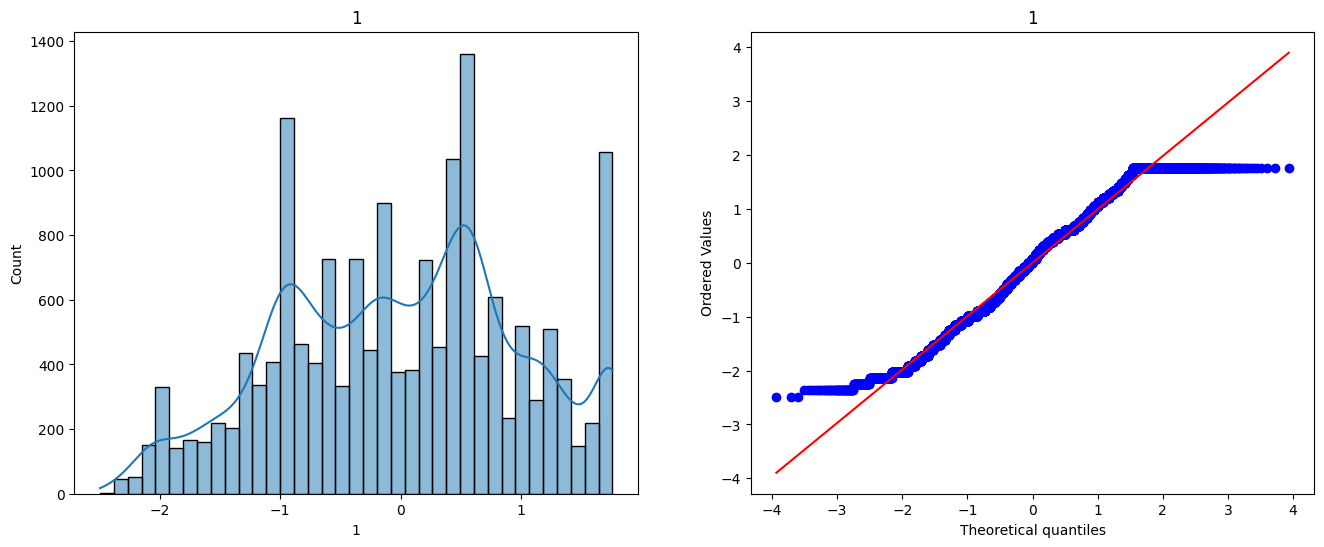

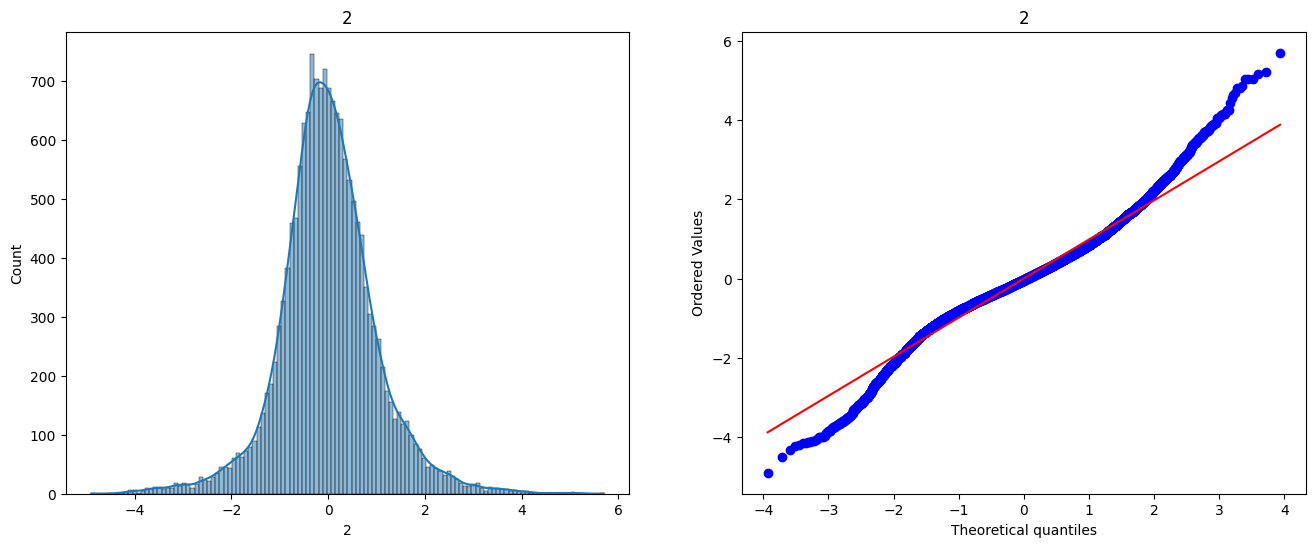

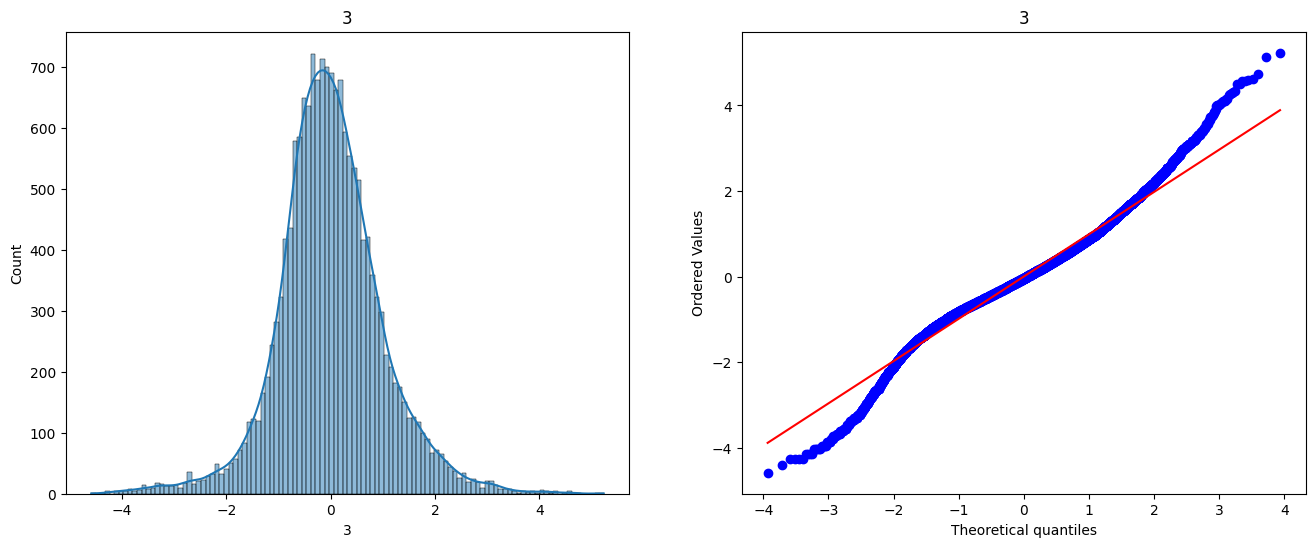

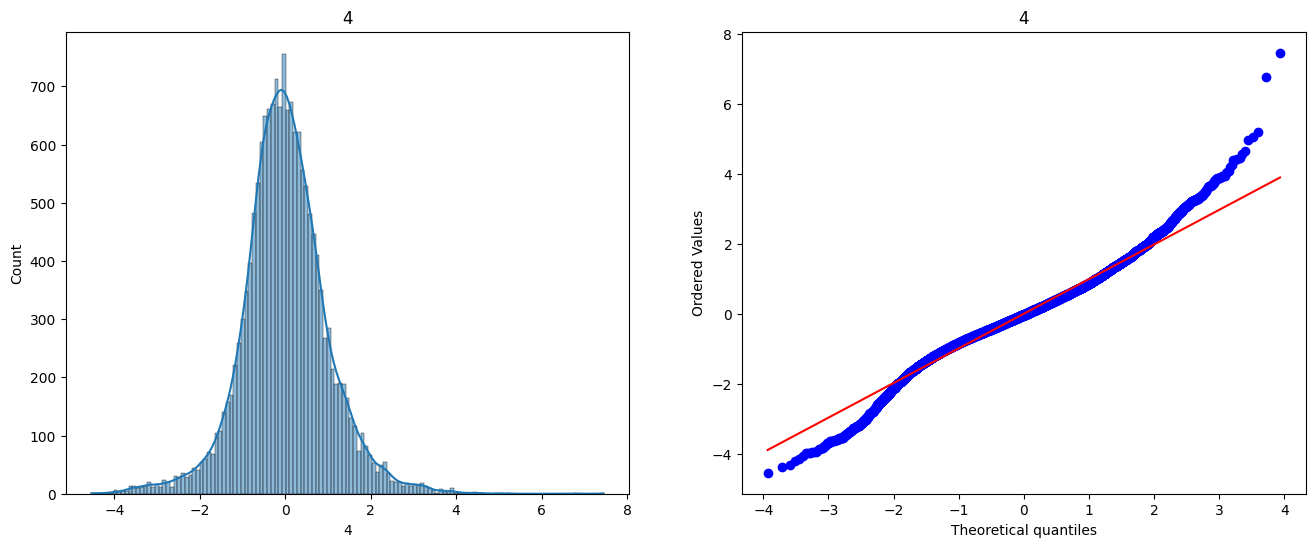

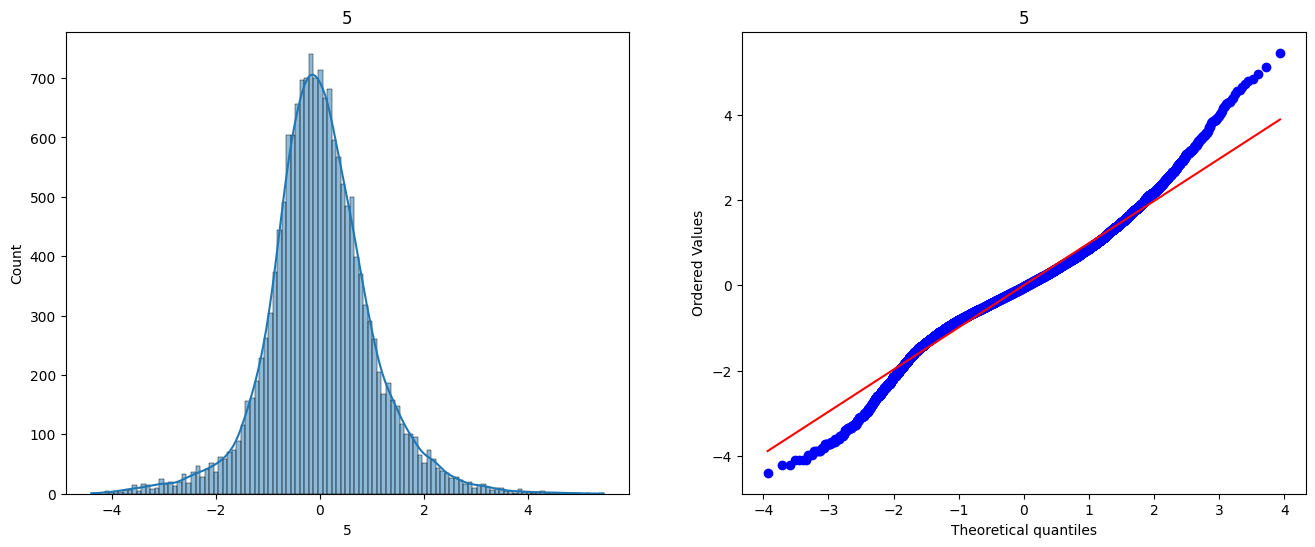

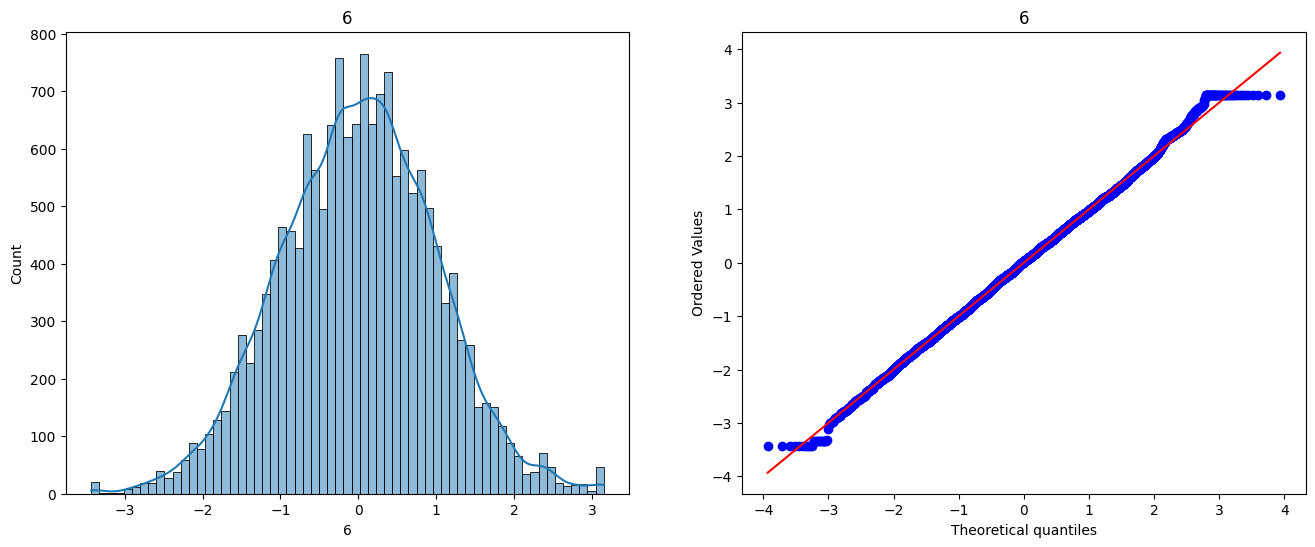

In [ ]:
# Plotting the histplots afte yeo johnsohn transformation

for col in x_train_transformed2.columns:
    plt.figure(figsize=(16,6))
    plt.subplot(121)
    sns.histplot(x_train_transformed2[col],kde=True)
    
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train_transformed2[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()